# 04 · Modelado y Visualización

**Fase CRISP-DM:** 4 de 6 — Modeling  
El "modelo" de este proyecto es descriptivo: la **capa semáforo** que superpone la serie medida con los umbrales operativos de referencia, más los cruces automáticos con comunicados. No hay modelo predictivo: predecir cotas no es el objetivo, mostrarlas sí.

In [1]:
import sys
from pathlib import Path

RAIZ = Path.cwd().parent
sys.path.insert(0, str(RAIZ / "src"))

import matplotlib.pyplot as plt
import pandas as pd

from constantes import EMBALSES, ARCHIVO_COTAS_RAW, DIR_FIGURAS
import visualizacion as viz

df = viz.cargar_cotas()
print(f"{len(df)} mediciones, {df['fecha'].min().date()} → {df['fecha'].max().date()}")

4899 mediciones, 2022-01-01 → 2026-08-15


## 1. Gráficos semáforo por embalse

Cada gráfico muestra:
- la serie diaria medida (azul),
- la **banda normal** de operación (sombra verde tenue, min–max),
- líneas de referencia mínima, máxima y crítica (donde aplica).

Los archivos quedan en `reports/figures/` para su publicación.

In [2]:
for embalse in EMBALSES:
    ruta = viz.serie_semaforo(df, embalse)
    print("figura →", ruta.name)

figura → semaforo_mazar.png


figura → semaforo_amaluza.png


figura → semaforo_sopladora.png


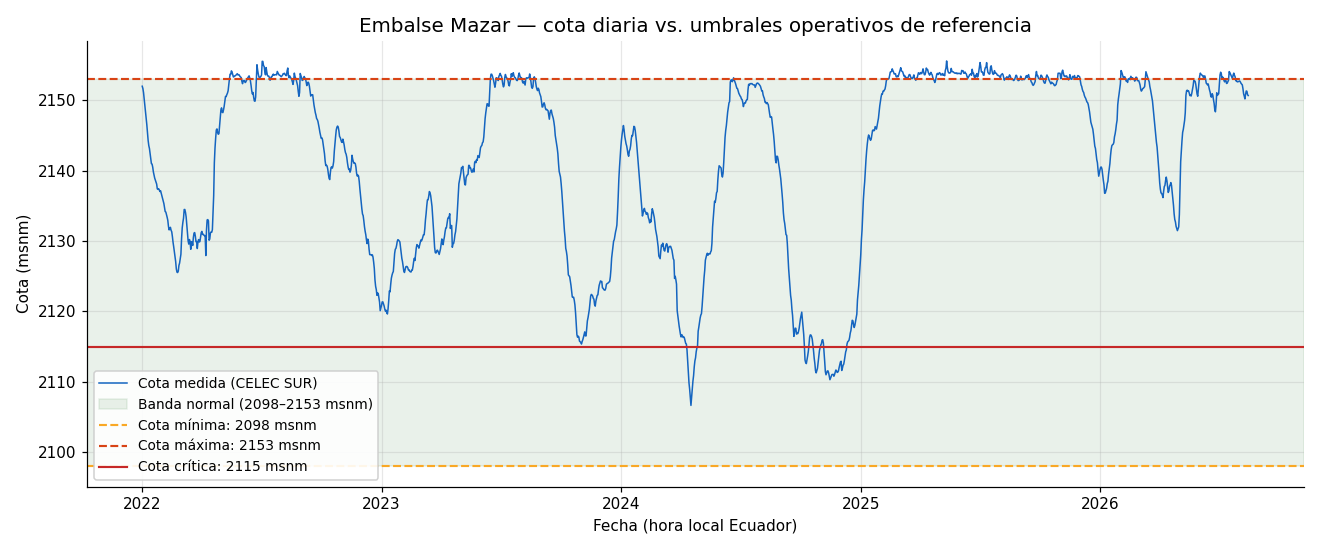

In [3]:
from IPython.display import Image, display
display(Image(filename=str(DIR_FIGURAS / "semaforo_mazar.png")))

## 2. Distancia al nivel crítico (Mazar)

Mazar es el único embalse del conjunto con nivel crítico declarado (2115 msnm). El gráfico de distancia expresa, en metros, cuán por encima (o por debajo) del crítico estuvo la cota cada día.

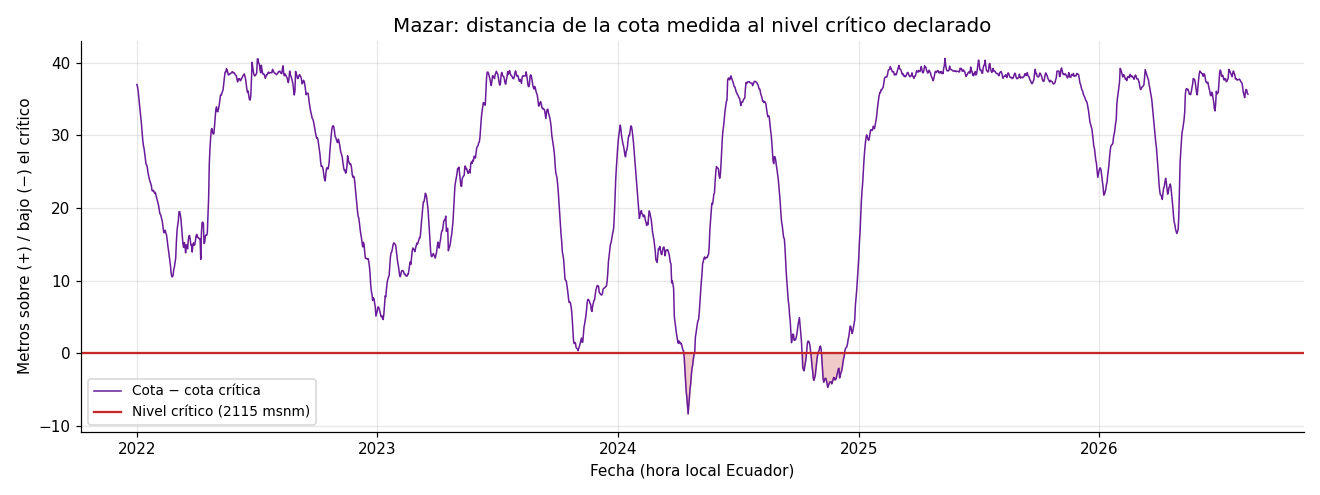

In [4]:
ruta = viz.distancia_a_critico(df, "Mazar")
if ruta:
    display(Image(filename=str(ruta)))

## 3. Comunicados sobre la serie

Líneas verticales punteadas marcan los días con comunicado oficial registrado en `data/comunicados/comunicados.csv`. Con el registro vacío el gráfico es idéntico salvo las marcas — así debe ser: el código no depende de que existan comunicados.

In [5]:
try:
    com = pd.read_csv(RAIZ / "data" / "comunicados" / "comunicados.csv").dropna(subset=["fecha"])
except Exception:
    com = None
for embalse in EMBALSES:
    ruta = viz.comparativo_comunicados(df, com, embalse)
    print("figura →", ruta.name)

figura → comunicados_mazar.png
figura → comunicados_amaluza.png


figura → comunicados_sopladora.png


## 4. Tabla de contexto por comunicado

Para cada comunicado registrado: cota medida del día, cota 7 días antes, variación y posición respecto a los umbrales. **La tabla no emite juicios**; presenta los números que corresponden a la fecha de cada declaración.

In [6]:
archivo_proc = RAIZ / "data" / "processed" / "comunicados_con_cota.csv"
if archivo_proc.exists():
    tabla_com = pd.read_csv(archivo_proc)
    display(tabla_com)
else:
    print("Sin comunicados registrados aún. Registrar filas en data/comunicados/comunicados.csv")
    print("y re-ejecutar 03_preparacion_datos.ipynb → 04_modelado_visualizacion.ipynb.")

Sin comunicados registrados aún. Registrar filas en data/comunicados/comunicados.csv
y re-ejecutar 03_preparacion_datos.ipynb → 04_modelado_visualizacion.ipynb.


## 5. Contexto trimestral

Resumen trimestral de cotas (media, mínimo, máximo y % de días dentro de banda). Es el contexto temporal con el que leer cualquier declaración de un trimestre dado.

**Nota de alcance:** el cruce con generación eléctrica trimestral requiere un dataset de generación (CENACE / datosabiertos.gob.ec) descargado localmente; cuando se incorpore, este bloque es el punto de integración.

In [7]:
tabla = df.pivot_table(index="fecha", columns="embalse", values="cota_msnm", aggfunc="last")
trimestral = tabla.resample("QS").agg(["mean", "min", "max"])
trimestral.columns = [f"{embalse}_{estadistico}" for embalse, estadistico in trimestral.columns]
trimestral.round(2).tail(8)

,Amaluza_mean,Amaluza_min,Amaluza_max,Mazar_mean,Mazar_min,Mazar_max,Sopladora_mean,Sopladora_min,Sopladora_max
fecha,,,,,,,,,
2024-10-01,1982.59,1978.39,1987.20,2114.62,2110.31,2125.10,1315.06,1313.76,1316.35
2025-01-01,1989.05,1985.65,1991.03,2149.50,2128.03,2154.60,1314.94,1313.77,1316.56
2025-04-01,1990.59,1987.17,1991.21,2153.77,2152.50,2155.56,1315.46,1313.71,1316.96
2025-07-01,1990.43,1988.25,1991.49,2153.45,2152.09,2155.33,1315.50,1314.14,1316.38
2025-10-01,1988.83,1985.91,1990.95,2151.19,2139.20,2154.25,1315.64,1313.58,1317.00
2026-01-01,1986.40,1982.68,1990.89,2148.35,2136.77,2154.19,1315.85,1314.26,1317.18
2026-04-01,1984.30,1978.65,1990.92,2145.45,2131.47,2153.83,1315.50,1314.05,1317.13
2026-07-01,1987.63,1984.31,1990.95,2152.54,2150.17,2154.05,1315.83,1313.51,1317.12


## 6. Regenerar todas las figuras de una vez

Equivalente CLI: `python src/visualizacion.py`

In [8]:
for ruta in viz.generar_todas():
    print("figura →", ruta.name)

figura → semaforo_mazar.png
figura → distancia_critico_mazar.png
figura → comunicados_mazar.png
figura → semaforo_amaluza.png
figura → comunicados_amaluza.png
figura → semaforo_sopladora.png
figura → comunicados_sopladora.png
